# Synthetic PCB Dataset Evaluation — DINOv2
Same evaluation pipeline as `evaluate_synthetic.ipynb` but uses **DINOv2 ViT-S/14** for embeddings instead of DenseNet121.
DINOv2 is self-supervised and generalises better to out-of-distribution domains than ImageNet-supervised models.

- **Embeddings (Vendi, UMAP, PRDC):** DINOv2 ViT-S/14 → 384-d features
- **FID / KID:** InceptionV3 via torchmetrics (kept as standard benchmark)
- **PCB-domain metrics:** LAB histograms, gradient magnitude, FFT — unchanged

In [1]:
# %pip install torchmetrics umap-learn vendi-score scikit-learn prdc imagehash -q

In [2]:
import os, random, warnings
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from scipy.stats import wasserstein_distance, ks_2samp
warnings.filterwarnings('ignore')

# ── paths ────────────────────────────────────────────────────────────────────
REAL_DIR = '../datasets/pcb-defect-dataset/train/images'
GEN_DIR  = '../datasets/generated_dataset/defects/images'

# ── config ───────────────────────────────────────────────────────────────────
N     = 3000
SEED  = 42
BATCH = 32

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

# torchmetrics FID/KID (InceptionV3) not fully supported on MPS
METRIC_DEVICE = 'cpu' if DEVICE == 'mps' else DEVICE

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f'device: {DEVICE}  |  metric device: {METRIC_DEVICE}')

device: mps  |  metric device: cpu


## 1. Load image paths

In [3]:
def collect_paths(folder):
    exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    return [os.path.join(folder, f) for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in exts]

all_real = collect_paths(REAL_DIR)
all_gen  = collect_paths(GEN_DIR)
print(f'found — real: {len(all_real)}  gen: {len(all_gen)}')

found — real: 8534  gen: 3000


## 2. Deduplication

In [4]:
import imagehash

TMP_REAL = 'tmp_dedup/real'
TMP_GEN  = 'tmp_dedup/gen'
os.makedirs(TMP_REAL, exist_ok=True)
os.makedirs(TMP_GEN,  exist_ok=True)

PHASH_THRESHOLD = 8

def dedup_by_phash(paths, out_dir, threshold):
    kept_paths, kept_hashes = [], []
    for p in tqdm(paths, desc='hashing real'):
        h = imagehash.phash(Image.open(p).convert('RGB'))
        if all(h - kh > threshold for kh in kept_hashes):
            kept_paths.append(p)
            kept_hashes.append(h)
            dst = os.path.join(out_dir, os.path.basename(p))
            if not os.path.lexists(dst):
                os.symlink(os.path.abspath(p), dst)
    return kept_paths

def dedup_gen_by_layout(paths, out_dir):
    seen, kept = set(), []
    for p in sorted(paths):
        layout_id = os.path.basename(p).split('_rep')[0]
        if layout_id not in seen:
            seen.add(layout_id)
            kept.append(p)
            dst = os.path.join(out_dir, os.path.basename(p))
            if not os.path.lexists(dst):
                os.symlink(os.path.abspath(p), dst)
    return kept

print(f'deduplicating real ({len(all_real)} images), phash threshold={PHASH_THRESHOLD}...')
unique_real = dedup_by_phash(all_real, TMP_REAL, PHASH_THRESHOLD)

print(f'deduplicating gen ({len(all_gen)} images) by layout prefix...')
unique_gen = dedup_gen_by_layout(all_gen, TMP_GEN)

real_paths = random.sample(unique_real, min(N, len(unique_real)))
gen_paths  = list(unique_gen[:min(N, len(unique_gen))])

print(f'\nbefore dedup — real: {len(all_real)}   gen: {len(all_gen)}')
print(f'after  dedup — real: {len(unique_real)}  gen: {len(unique_gen)}')
print(f'used for eval — real: {len(real_paths)}  gen: {len(gen_paths)}')

deduplicating real (8534 images), phash threshold=8...


hashing real: 100%|██████████| 8534/8534 [00:14<00:00, 578.73it/s]


deduplicating gen (3000 images) by layout prefix...

before dedup — real: 8534   gen: 3000
after  dedup — real: 164  gen: 500
used for eval — real: 164  gen: 500


## 3. DINOv2 feature extraction
Using `dinov2_vits14` (ViT-S/14, 384-d CLS token). First run downloads ~85 MB to torch hub cache.

In [5]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# DINOv2 expects 224×224, multiples of patch size 14; same ImageNet normalisation
dino_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class PathDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.transform(Image.open(self.paths[i]).convert('RGB'))

print('loading DINOv2 ViT-S/14 (~85 MB download on first run)...')
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', verbose=False)
dinov2 = dinov2.to(DEVICE).eval()
print('model loaded')

def extract_embeddings(paths):
    loader = DataLoader(PathDataset(paths, dino_transform), batch_size=BATCH, num_workers=0)
    parts = []
    with torch.no_grad():
        for batch in tqdm(loader):
            parts.append(dinov2(batch.to(DEVICE)).cpu().numpy())
    return np.vstack(parts)

print('extracting real embeddings...')
real_emb = extract_embeddings(real_paths)
print('extracting gen embeddings...')
gen_emb  = extract_embeddings(gen_paths)
print(f'embedding shapes — real: {real_emb.shape}  gen: {gen_emb.shape}')

loading DINOv2 ViT-S/14 (~85 MB download on first run)...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /Users/alexblokh/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /Users/alexblokh/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:08<00:00, 10.1MB/s]


model loaded
extracting real embeddings...


100%|██████████| 6/6 [00:02<00:00,  2.23it/s]


extracting gen embeddings...


100%|██████████| 16/16 [00:07<00:00,  2.15it/s]

embedding shapes — real: (164, 384)  gen: (500, 384)


## 4. FID & KID (InceptionV3 — standard benchmark)

In [6]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

fid_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
])

def load_uint8_tensors(paths):
    loader = DataLoader(PathDataset(paths, fid_transform), batch_size=BATCH, num_workers=0)
    parts = []
    for batch in tqdm(loader):
        parts.append((batch * 255).to(torch.uint8))
    return torch.cat(parts)

print('loading tensors for FID/KID...')
real_u8 = load_uint8_tensors(real_paths)
gen_u8  = load_uint8_tensors(gen_paths)

loading tensors for FID/KID...


100%|██████████| 16/16 [00:03<00:00,  5.11it/s]


In [7]:
def compute_fid(real_t, gen_t):
    metric = FrechetInceptionDistance(feature=2048).to(METRIC_DEVICE)
    for i in tqdm(range(0, len(real_t), BATCH)):
        metric.update(real_t[i:i+BATCH].to(METRIC_DEVICE), real=True)
    for i in tqdm(range(0, len(gen_t), BATCH)):
        metric.update(gen_t[i:i+BATCH].to(METRIC_DEVICE), real=False)
    return metric.compute().item()

def compute_kid(real_t, gen_t):
    subset_size = min(1000, len(real_t), len(gen_t)) - 1
    metric = KernelInceptionDistance(feature=2048, subset_size=subset_size).to(METRIC_DEVICE)
    for i in tqdm(range(0, len(real_t), BATCH)):
        metric.update(real_t[i:i+BATCH].to(METRIC_DEVICE), real=True)
    for i in tqdm(range(0, len(gen_t), BATCH)):
        metric.update(gen_t[i:i+BATCH].to(METRIC_DEVICE), real=False)
    mean, std = metric.compute()
    return mean.item(), std.item()

print('computing FID (gen vs real)...')
fid_gen = compute_fid(real_u8, gen_u8)

mid = len(real_u8) // 2
print('computing FID baseline (real-A vs real-B)...')
fid_base = compute_fid(real_u8[:mid], real_u8[mid:])

print('computing KID...')
kid_mean, kid_std = compute_kid(real_u8, gen_u8)

print(f'\nFID  gen vs real : {fid_gen:.2f}')
print(f'FID  baseline    : {fid_base:.2f}')
print(f'KID              : {kid_mean:.4f} ± {kid_std:.4f}')

computing FID (gen vs real)...


100%|██████████| 16/16 [00:51<00:00,  3.22s/it]


computing FID baseline (real-A vs real-B)...


100%|██████████| 3/3 [00:08<00:00,  2.85s/it]


computing KID...


100%|██████████| 16/16 [00:52<00:00,  3.26s/it]


FID  gen vs real : 295.07
FID  baseline    : 48.63
KID              : 0.4133 ± 0.0066


## 5. Vendi Score (DINOv2 embeddings)

In [8]:
from vendi_score import vendi

vendi_real = vendi.score_X(real_emb)
vendi_gen  = vendi.score_X(gen_emb)

print(f'Vendi real : {vendi_real:.2f}')
print(f'Vendi gen  : {vendi_gen:.2f}')
print(f'ratio      : {vendi_real / vendi_gen:.2f}x')

Vendi real : 2.44
Vendi gen  : 1.41
ratio      : 1.72x


## 6. Precision, Recall, Density, Coverage (DINOv2 embeddings)

In [9]:
from prdc import compute_prdc

prdc_metrics = compute_prdc(
    real_features=real_emb,
    fake_features=gen_emb,
    nearest_k=5
)

print('Precision (fidelity) :', round(prdc_metrics['precision'], 4))
print('Recall    (coverage)  :', round(prdc_metrics['recall'],    4))
print('Density               :', round(prdc_metrics['density'],   4))
print('Coverage              :', round(prdc_metrics['coverage'],  4))

Num real: 164 Num fake: 500
Precision (fidelity) : 0.156
Recall    (coverage)  : 0.0
Density               : 0.0488
Coverage              : 0.0244


## 7. UMAP overlay (DINOv2 embeddings)

fitting UMAP...


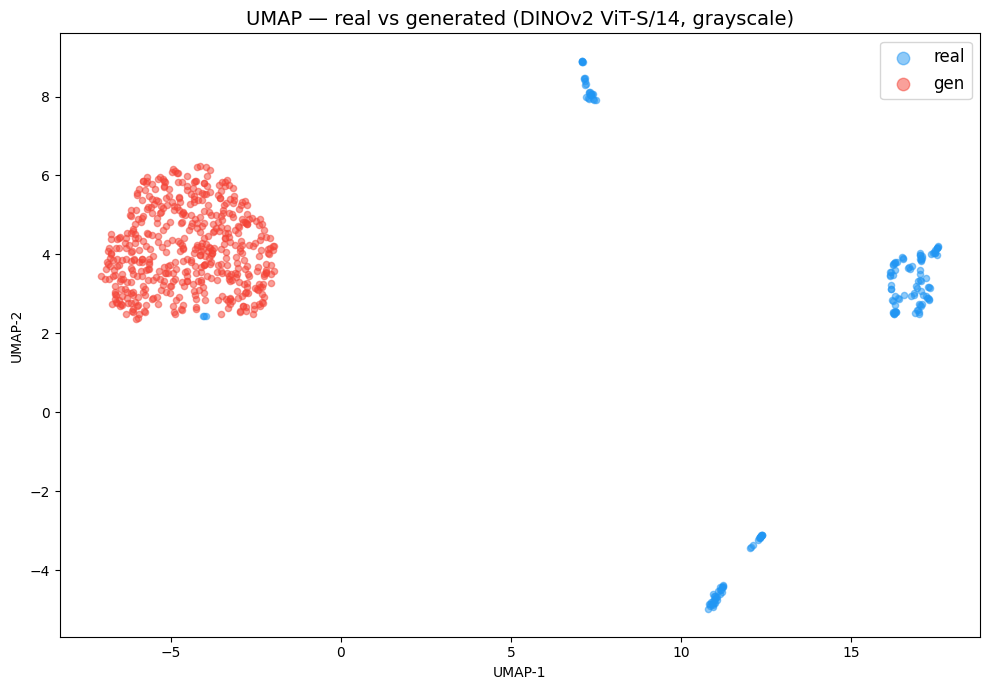

In [10]:
import umap

combined = np.vstack([real_emb, gen_emb])
labels   = np.array(['real'] * len(real_emb) + ['gen'] * len(gen_emb))

print('fitting UMAP...')
reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
proj    = reducer.fit_transform(combined)

fig, ax = plt.subplots(figsize=(10, 7))
for label, color in [('real', '#2196F3'), ('gen', '#F44336')]:
    mask = labels == label
    ax.scatter(proj[mask, 0], proj[mask, 1],
               c=color, alpha=0.5, s=20, label=label)
ax.set_title('UMAP — real vs generated (DINOv2 ViT-S/14, grayscale)', fontsize=14)
ax.legend(markerscale=2, fontsize=12)
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
plt.tight_layout()
plt.show()

## 8. PCB-domain metrics

### 8a. Color histograms (LAB) — generator diagnostic, not task metric

sampling color histograms...


100%|██████████| 500/500 [00:05<00:00, 91.34it/s]


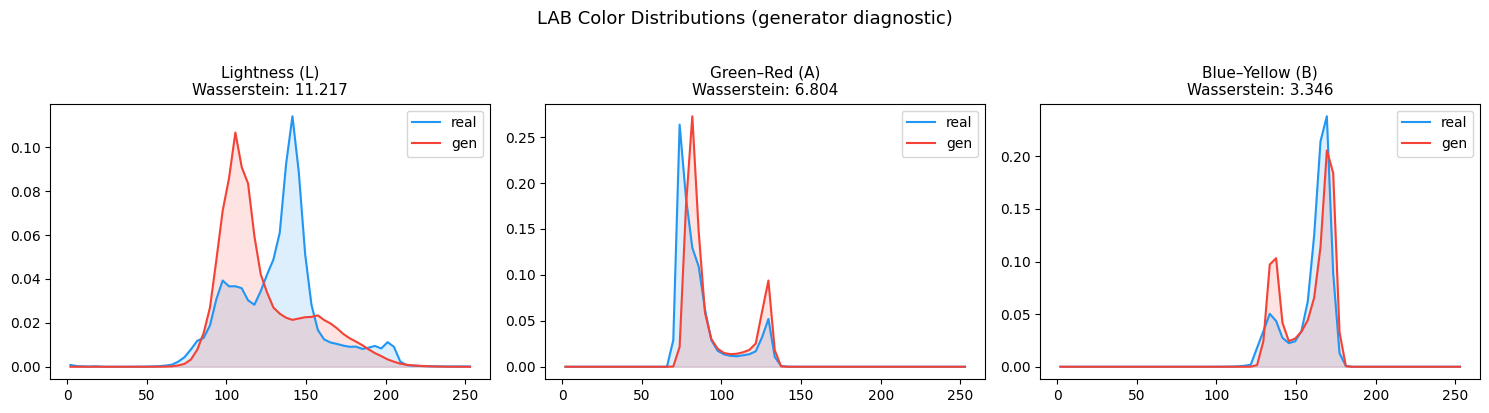

In [11]:
def sample_lab_histograms(paths, n_sample=500, bins=64):
    hists = {c: np.zeros(bins) for c in ('L', 'A', 'B')}
    for p in tqdm(random.sample(paths, min(n_sample, len(paths)))):
        img = cv2.imread(p)
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
        for ci, ch in enumerate(('L', 'A', 'B')):
            h, _ = np.histogram(lab[:, :, ci].ravel(), bins=bins, range=(0, 255))
            hists[ch] += h
    for ch in hists:
        hists[ch] /= hists[ch].sum()
    return hists

print('sampling color histograms...')
real_hists = sample_lab_histograms(real_paths)
gen_hists  = sample_lab_histograms(gen_paths)

bins    = np.linspace(0, 255, 65)
centers = (bins[:-1] + bins[1:]) / 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channel_names = {'L': 'Lightness (L)', 'A': 'Green–Red (A)', 'B': 'Blue–Yellow (B)'}
wass = {}
for ax, ch in zip(axes, ('L', 'A', 'B')):
    ax.plot(centers, real_hists[ch], label='real',  color='#2196F3', linewidth=1.5)
    ax.plot(centers, gen_hists[ch],  label='gen',   color='#F44336', linewidth=1.5)
    ax.fill_between(centers, real_hists[ch], alpha=0.15, color='#2196F3')
    ax.fill_between(centers, gen_hists[ch],  alpha=0.15, color='#F44336')
    w = wasserstein_distance(centers, centers, real_hists[ch], gen_hists[ch])
    wass[ch] = w
    ax.set_title(f'{channel_names[ch]}\nWasserstein: {w:.3f}', fontsize=11)
    ax.legend()
plt.suptitle('LAB Color Distributions (generator diagnostic)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 8b. Gradient magnitude distribution

computing gradient magnitudes...


100%|██████████| 500/500 [00:02<00:00, 181.01it/s]


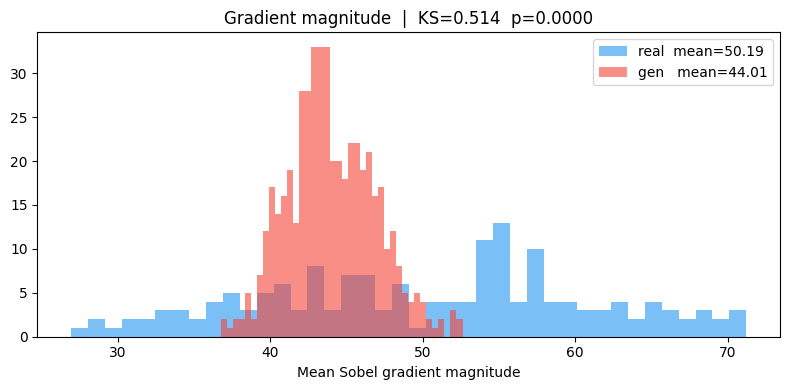

In [12]:
def gradient_magnitudes(paths, n_sample=500):
    mags = []
    for p in tqdm(random.sample(paths, min(n_sample, len(paths)))):
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        gx  = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        gy  = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        mags.append(np.mean(np.sqrt(gx**2 + gy**2)))
    return np.array(mags)

print('computing gradient magnitudes...')
real_grads = gradient_magnitudes(real_paths)
gen_grads  = gradient_magnitudes(gen_paths)

ks_stat, ks_p = ks_2samp(real_grads, gen_grads)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(real_grads, bins=40, alpha=0.6, color='#2196F3', label=f'real  mean={real_grads.mean():.2f}')
ax.hist(gen_grads,  bins=40, alpha=0.6, color='#F44336', label=f'gen   mean={gen_grads.mean():.2f}')
ax.set_title(f'Gradient magnitude  |  KS={ks_stat:.3f}  p={ks_p:.4f}', fontsize=12)
ax.set_xlabel('Mean Sobel gradient magnitude')
ax.legend()
plt.tight_layout()
plt.show()

### 8c. FFT power spectrum

computing FFT power spectra...


100%|██████████| 200/200 [00:01<00:00, 123.04it/s]


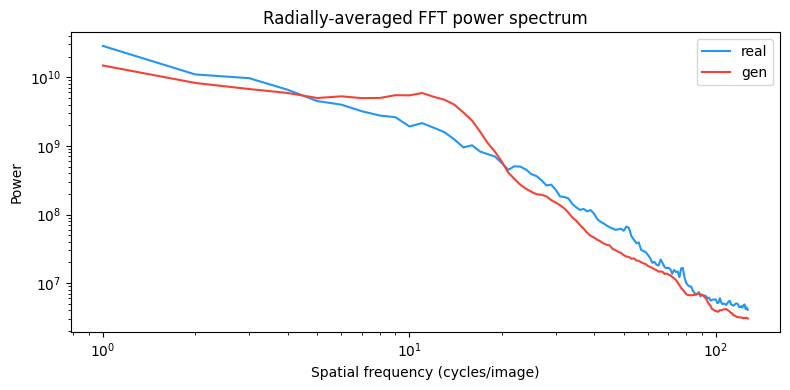

In [13]:
def radial_power_spectrum(paths, n_sample=200, size=256):
    half = size // 2
    y, x = np.indices((size, size)) - half
    r     = np.sqrt(x**2 + y**2).astype(int)
    power_sum = np.zeros(half)
    sampled = random.sample(paths, min(n_sample, len(paths)))
    for p in tqdm(sampled):
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (size, size)).astype(np.float32)
        mag = np.abs(np.fft.fftshift(np.fft.fft2(img))) ** 2
        for ri in range(half):
            mask = r == ri
            if mask.any():
                power_sum[ri] += mag[mask].mean()
    return power_sum / len(sampled)

print('computing FFT power spectra...')
real_ps = radial_power_spectrum(real_paths)
gen_ps  = radial_power_spectrum(gen_paths)

freqs = np.arange(1, len(real_ps))
fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(freqs, real_ps[1:], color='#2196F3', linewidth=1.5, label='real')
ax.loglog(freqs, gen_ps[1:],  color='#F44336', linewidth=1.5, label='gen')
ax.set_title('Radially-averaged FFT power spectrum', fontsize=12)
ax.set_xlabel('Spatial frequency (cycles/image)')
ax.set_ylabel('Power')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Summary

In [14]:
from IPython.display import Markdown, display

rows = [
    ('FID (gen vs real)',      f'{fid_gen:.2f}',                    f'baseline real-vs-real: {fid_base:.2f} | InceptionV3'),
    ('KID',                    f'{kid_mean:.4f} ± {kid_std:.4f}',   'lower is better | InceptionV3'),
    ('Vendi Score — real',     f'{vendi_real:.2f}',                 'effective # of distinct images | DINOv2'),
    ('Vendi Score — gen',      f'{vendi_gen:.2f}',                  f'ratio: {vendi_real/vendi_gen:.2f}x | DINOv2'),
    ('Precision',              f"{prdc_metrics['precision']:.4f}",  '% gen in real manifold | DINOv2'),
    ('Recall',                 f"{prdc_metrics['recall']:.4f}",     '% real covered by gen | DINOv2'),
    ('Density',                f"{prdc_metrics['density']:.4f}",    'DINOv2'),
    ('Coverage',               f"{prdc_metrics['coverage']:.4f}",   'DINOv2'),
    ('Wasserstein L',          f"{wass['L']:.4f}",                  'LAB lightness'),
    ('Wasserstein A',          f"{wass['A']:.4f}",                  'LAB green–red'),
    ('Wasserstein B',          f"{wass['B']:.4f}",                  'LAB blue–yellow'),
    ('Grad mag mean — real',   f'{real_grads.mean():.2f}',          'Sobel texture complexity'),
    ('Grad mag mean — gen',    f'{gen_grads.mean():.2f}',           ''),
    ('KS stat (grad mag)',     f'{ks_stat:.4f}',                    f'p={ks_p:.4f}'),
]

header = '| Metric | Value | Notes |\n|---|---|---|\n'
body   = '\n'.join(f'| {m} | {v} | {n} |' for m, v, n in rows)
display(Markdown(header + body))

| Metric | Value | Notes |
|---|---|---|
| FID (gen vs real) | 295.07 | baseline real-vs-real: 48.63 | InceptionV3 |
| KID | 0.4133 ± 0.0066 | lower is better | InceptionV3 |
| Vendi Score — real | 2.44 | effective # of distinct images | DINOv2 |
| Vendi Score — gen | 1.41 | ratio: 1.72x | DINOv2 |
| Precision | 0.1560 | % gen in real manifold | DINOv2 |
| Recall | 0.0000 | % real covered by gen | DINOv2 |
| Density | 0.0488 | DINOv2 |
| Coverage | 0.0244 | DINOv2 |
| Wasserstein L | 11.2171 | LAB lightness |
| Wasserstein A | 6.8037 | LAB green–red |
| Wasserstein B | 3.3456 | LAB blue–yellow |
| Grad mag mean — real | 50.19 | Sobel texture complexity |
| Grad mag mean — gen | 44.01 |  |
| KS stat (grad mag) | 0.5145 | p=0.0000 |